# Super-Scout — dataset, grafo e valutazione in grafici

Questo notebook mostra, con dati letti direttamente dalle fonti del progetto:

1. **il dataset di partenza** — cosa contiene l'*European Soccer Database* e, soprattutto, **quanto è disomogenea la copertura degli eventi di gioco**, che è il limite da dichiarare in ogni risposta;
2. **il grafo costruito** — quante relazioni, di che tipo, e quanta parte di esse **non esiste nella sorgente** ma è derivata al caricamento;
3. **le relazioni e la loro semantica** — ruoli ricavati dalle coordinate di schieramento, serie temporale delle valutazioni;
4. **i risultati della valutazione** — il benchmark con i guardrail attivi contro l'ablazione senza guardrail, le metriche di efficacia, i guardrail che intervengono e dove va il tempo.

**Fonti dei dati.** Nessun numero è scritto a mano, tranne dove indicato: `data/raw/database.sqlite` (la sorgente), Neo4j (il grafo, letto via `app.graph.GraphStore`), `evaluation/results/*.json` (i record grezzi del benchmark). L'unica tabella riportata da documento è la scala delle traversate (esperimento sulla scala delle traversate, `README.md` §6.5), che richiede il riavvio del database e non si rifà qui: la cella lo dichiara.

**Come eseguirlo.**

```bash
docker compose up -d
docker compose exec api pip install -r notebooks/requirements.txt
docker compose exec api jupyter lab --ip 0.0.0.0 --port 8888 --no-browser --allow-root
```

Poi aprire l'indirizzo con il token stampato a terminale. Ogni sezione degrada da sola: se Neo4j o lo SQLite non sono raggiungibili, le celle che dipendono da loro lo dicono e il resto continua a funzionare.

## 0. Impostazioni comuni

La tavolozza è quella della guida di visualizzazione del progetto, validata per separazione sotto daltonismo e contrasto sulla superficie chiara. Tre regole tengono insieme tutti i grafici che seguono:

- **una grandezza da confrontare → una sola tinta** (blu, più scuro = più grande): la scala sequenziale non si può fraintendere;
- **serie da distinguere → tinte categoriali in ordine fisso** (blu, arancio, verde acqua, giallo), mai generate al volo;
- **nessun doppio asse**, etichette diritte sui valori invece di una griglia fitta.

In [1]:
from pathlib import Path
import json, sqlite3, textwrap
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB = ROOT / "data" / "raw" / "database.sqlite"
RESULTS = ROOT / "evaluation" / "results"

# --- tavolozza validata (docs: guida di visualizzazione) ---------------------
SURFACE     = "#fcfcfb"
INK         = "#0b0b0b"
INK_SOFT    = "#52514e"
GRID        = "#dcdbd6"
SEQ         = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
               "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
CAT         = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # ordine fisso, mai ciclato
GOOD, CRIT  = "#0ca30c", "#d03b3b"                            # stato: sempre con etichetta

def seq_scale(values, lo=4, hi=12):
    """Una tinta sola, più scuro = più grande: la scala del confronto di grandezza."""
    top = max(values) or 1
    return [SEQ[min(hi, lo + int((hi - lo) * (v / top)))] for v in values]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlepad": 14,
    "figure.dpi": 110, "savefig.bbox": "tight", "axes.spines.top": False, "axes.spines.right": False,
})

def style(ax, title=None, subtitle=None, xlabel=None, ylabel=None, grid_axis="x"):
    """Titolo + sottotitolo che dice cosa leggere, griglia discreta, assi puliti."""
    # Un sottotitolo lungo allargherebbe la figura oltre le altre: va a capo. Lo
    # spazio sopra il titolo si calcola dalle righe che ne risultano, in punti:
    # una frazione degli assi dipenderebbe dall'altezza della figura.
    wrapped = "\n".join(textwrap.wrap(subtitle, width=112)) if subtitle else ""
    if title:
        ax.set_title(title, loc="left", pad=16 + 14 * wrapped.count("\n") + (14 if subtitle else -4))
    if subtitle:
        ax.annotate(wrapped, xy=(0, 1), xycoords="axes fraction", xytext=(0, 8),
                    textcoords="offset points", fontsize=9.5, color=INK_SOFT, va="bottom",
                    linespacing=1.45)
    ax.set_xlabel(xlabel or "", fontsize=9.5)
    ax.set_ylabel(ylabel or "", fontsize=9.5)
    if grid_axis:                      # grid_axis="" = nessuna griglia (heatmap, barra unica)
        ax.grid(axis=grid_axis, alpha=0.7, zorder=0)
    else:
        ax.grid(False)
    ax.set_axisbelow(True)
    return ax

def bar_labels(ax, bars, values, fmt="{:,.0f}", pad=0.01, inside_from=0.72, log=False):
    """Etichetta diretta su ogni barra: niente numeri da inseguire sulla griglia.

    Su scala logaritmica lo scostamento è moltiplicativo: uno spostamento
    lineare lascerebbe le etichette delle barre corte a mezz'aria.
    """
    span = max(values) or 1
    for bar, value in zip(bars, values):
        inside = (value / span > inside_from) if not log else False
        if log:
            place = bar.get_width() * 1.3
        else:
            place = bar.get_width() - span * pad if inside else bar.get_width() + span * pad
        ax.text(place,
                bar.get_y() + bar.get_height() / 2, fmt.format(value).replace(",", "."),
                va="center", ha="right" if inside else "left", fontsize=9.5,
                color=SURFACE if inside else INK_SOFT, fontweight="bold" if inside else "normal")

print(f"progetto: {ROOT}")
print(f"dataset:  {'presente' if DB.exists() else 'ASSENTE (le sezioni 1 e 3 lo diranno)'}")
print(f"risultati benchmark: {sorted(p.name for p in RESULTS.glob('*.json'))}")

progetto: /app
dataset:  presente
risultati benchmark: ['baseline.json', 'no-guardrails.json', 'post-fix-marcatore.json', 'post-fix.json']


In [2]:
# Connessioni alle due sorgenti. Entrambe facoltative: se mancano, le celle che
# le usano stampano un avviso e il resto del notebook continua.
def sqlite_connection():
    return sqlite3.connect(DB) if DB.exists() else None

def graph_query(cypher, parameters=None):
    try:
        import sys; sys.path.insert(0, str(ROOT))
        from app.graph import GraphStore
    except Exception as error:
        print(f"[grafo non disponibile: {error}]"); return None
    try:
        store = GraphStore()
        rows = store.query(cypher, parameters or {})
        store.close()
        return pd.DataFrame(rows)
    except Exception as error:
        print(f"[Neo4j non raggiungibile: {str(error).splitlines()[0]}]"); return None

conn = sqlite_connection()
probe = graph_query("MATCH (n) RETURN count(n) AS nodi")
if probe is not None:
    print(f"grafo: {int(probe.loc[0, 'nodi']):,} nodi".replace(",", "."))

grafo: 37.346 nodi


---

## 1. Il dataset di partenza

L'*European Soccer Database* è uno SQLite di sette tabelle: anagrafica di giocatori e squadre, 25.979 partite con formazioni a 22 slot, 183.978 valutazioni FIFA e 1.458 rilevazioni sullo stile delle squadre. Il dato più ricco però non è in una colonna: è **annidato in otto campi XML** della tabella `Match` (gol, tiri in porta e fuori, falli, cartellini, cross, corner, possesso).

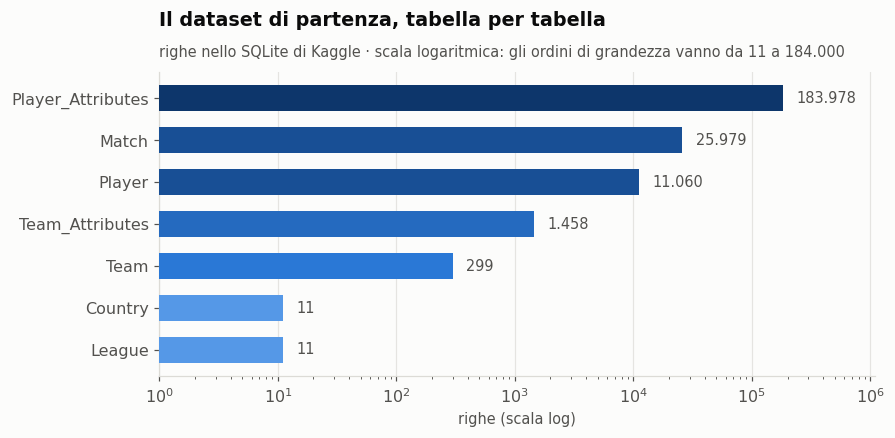

,righe
Player_Attributes,183978
Match,25979
Player,11060
Team_Attributes,1458
Team,299
Country,11
League,11


In [3]:
if conn is None:
    print("SQLite non presente: salto la sezione 1.")
else:
    tables = ["Player", "Team", "Match", "League", "Country", "Player_Attributes", "Team_Attributes"]
    counts = {t: conn.execute(f"SELECT count(*) FROM {t}").fetchone()[0] for t in tables}
    source = pd.Series(counts).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8.4, 3.6))
    import math
    magnitudes = [math.log10(v) for v in source.values]
    bars = ax.barh(source.index, source.values, color=seq_scale(magnitudes), height=0.62, zorder=3)
    bar_labels(ax, bars, source.values.tolist(), log=True)
    ax.set_xscale("log")
    ax.set_xlim(1, source.max() * 6)
    style(ax, "Il dataset di partenza, tabella per tabella",
          "righe nello SQLite di Kaggle · scala logaritmica: gli ordini di grandezza vanno da 11 a 184.000",
          xlabel="righe (scala log)")
    plt.show()
    display(source.sort_values(ascending=False).rename("righe").to_frame())

### 1.1 La copertura degli eventi: il limite da dichiarare

Gli otto XML non sono compilati ovunque. Questo grafico è la ragione per cui ogni risposta che usa un evento porta una nota sulla copertura, e ogni totale di stagione è accompagnato dal numero di partite coperte: **senza questa avvertenza una classifica di falli premia chi gioca in Inghilterra e condanna chi gioca in Belgio a zero.**

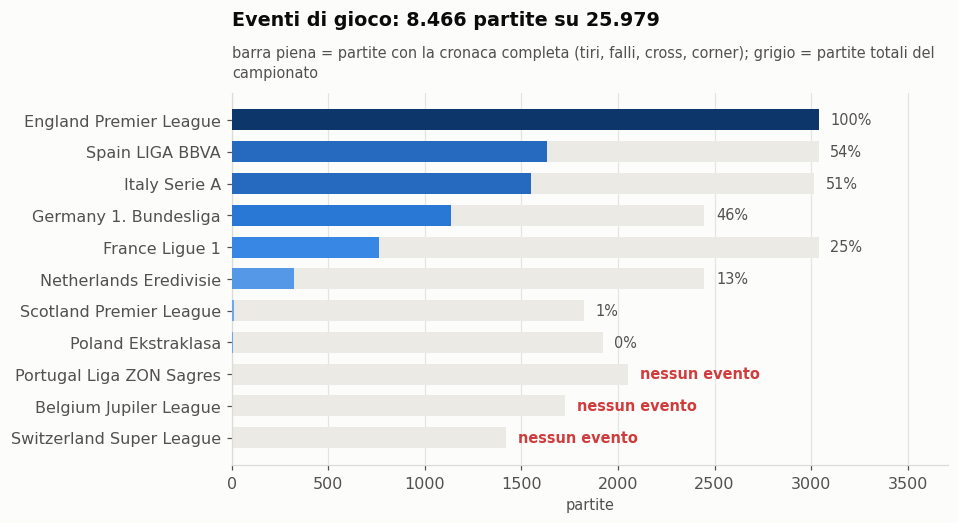

,campionato,partite,con_eventi,copertura
0,England Premier League,3040,3040,100.0
1,Spain LIGA BBVA,3040,1634,53.8
2,Italy Serie A,3017,1548,51.3
3,Germany 1. Bundesliga,2448,1134,46.3
4,France Ligue 1,3040,764,25.1
5,Netherlands Eredivisie,2448,323,13.2
6,Scotland Premier League,1824,13,0.7
7,Poland Ekstraklasa,1920,7,0.4
8,Portugal Liga ZON Sagres,2052,0,0.0
9,Belgium Jupiler League,1728,0,0.0


In [4]:
if conn is None:
    print("SQLite non presente: salto la sezione 1.1.")
else:
    coverage = pd.read_sql_query("""
        SELECT l.name AS campionato,
               count(*) AS partite,
               sum(CASE WHEN m.shoton IS NOT NULL AND length(m.shoton) > 20 THEN 1 ELSE 0 END) AS con_eventi
        FROM Match m JOIN League l ON l.id = m.league_id
        GROUP BY l.name ORDER BY 1.0 * con_eventi / partite DESC, partite DESC
    """, conn)
    coverage["copertura"] = 100 * coverage["con_eventi"] / coverage["partite"]

    fig, ax = plt.subplots(figsize=(8.4, 4.4))
    order = coverage.iloc[::-1]
    # Il totale in grigio chiaro è il contesto; la parte coperta è il dato.
    ax.barh(order["campionato"], order["partite"], color="#ebeae5", height=0.66, zorder=2)
    bars = ax.barh(order["campionato"], order["con_eventi"],
                   color=seq_scale(order["copertura"].tolist()), height=0.66, zorder=3)
    for bar, covered, total, pct in zip(bars, order["con_eventi"], order["partite"], order["copertura"]):
        ax.text(total + 60, bar.get_y() + bar.get_height() / 2,
                f"{pct:.0f}%" if pct else "nessun evento",
                va="center", fontsize=9.5, color=INK_SOFT if pct else CRIT,
                fontweight="bold" if pct == 0 else "normal")
    ax.set_xlim(0, coverage["partite"].max() * 1.22)
    style(ax, "Eventi di gioco: 8.466 partite su 25.979",
          "barra piena = partite con la cronaca completa (tiri, falli, cross, corner); grigio = partite totali del campionato",
          xlabel="partite")
    plt.show()
    display(coverage.assign(copertura=lambda d: d["copertura"].round(1)))

### 1.2 Le partite per stagione e campionato

Otto stagioni, undici campionati: la griglia mostra quanto è regolare il dataset sull'asse temporale (e dove un campionato entra o esce).

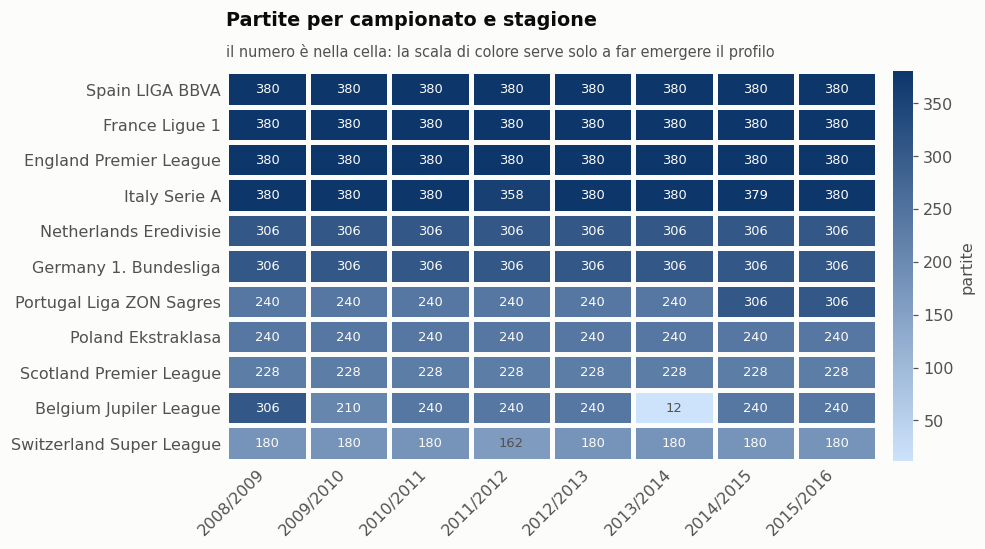

In [5]:
if conn is None:
    print("SQLite non presente: salto la sezione 1.2.")
else:
    grid = pd.read_sql_query("""
        SELECT l.name AS campionato, m.season AS stagione, count(*) AS partite
        FROM Match m JOIN League l ON l.id = m.league_id GROUP BY l.name, m.season
    """, conn).pivot(index="campionato", columns="stagione", values="partite").fillna(0)
    grid = grid.loc[grid.sum(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(9.2, 4.6))
    cmap = mpl.colors.LinearSegmentedColormap.from_list("blu", [SEQ[0], SEQ[-1]])
    mesh = ax.pcolormesh(grid.values, cmap=cmap, edgecolors=SURFACE, linewidth=2)
    ax.set_xticks([i + 0.5 for i in range(grid.shape[1])], grid.columns, rotation=45, ha="right")
    ax.set_yticks([i + 0.5 for i in range(grid.shape[0])], grid.index)
    for y in range(grid.shape[0]):
        for x in range(grid.shape[1]):
            value = int(grid.values[y, x])
            ax.text(x + 0.5, y + 0.5, value or "—", ha="center", va="center", fontsize=8.5,
                    color=SURFACE if value > grid.values.max() * 0.45 else INK_SOFT)
    ax.spines[:].set_visible(False)
    ax.tick_params(length=0)
    style(ax, "Partite per campionato e stagione", "il numero è nella cella: la scala di colore serve solo a far emergere il profilo", grid_axis="")
    plt.colorbar(mesh, ax=ax, pad=0.02, label="partite").outline.set_visible(False)
    plt.show()

---

## 2. Il grafo costruito

Il caricamento non copia le tabelle nel grafo: le **interpreta**. Il risultato è un knowledge graph di 37.346 nodi e quasi due milioni di relazioni, in cui la parte più utile allo scouting — chi gioca dove *oggi*, per chi giocava in una certa stagione, che ruolo copre, com'è andato il campionato — non esiste come colonna nella sorgente.

37.346 nodi · 1.952.560 relazioni · 20 tipi di relazione


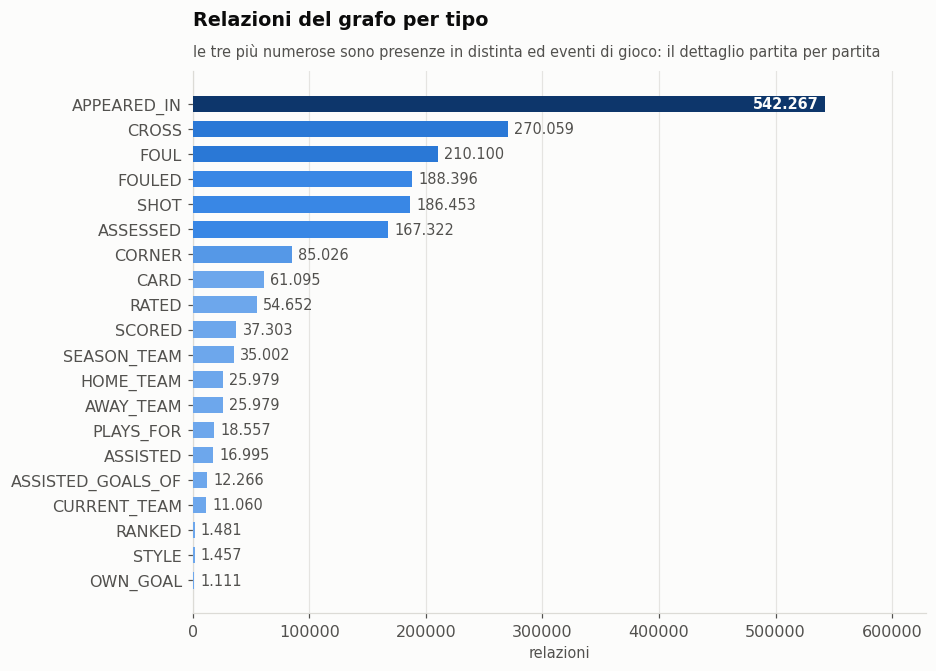

,tipo,n,quota
0,APPEARED_IN,542267,27.8
1,CROSS,270059,13.8
2,FOUL,210100,10.8
3,FOULED,188396,9.6
4,SHOT,186453,9.5
5,ASSESSED,167322,8.6
6,CORNER,85026,4.4
7,CARD,61095,3.1
8,RATED,54652,2.8
9,SCORED,37303,1.9


In [6]:
rels = graph_query("MATCH ()-[r]->() RETURN type(r) AS tipo, count(*) AS n ORDER BY n DESC")
nodes = graph_query("MATCH (n) RETURN labels(n)[0] AS etichetta, count(*) AS n ORDER BY n DESC")

if rels is not None and nodes is not None:
    print(f"{int(nodes['n'].sum()):,} nodi · {int(rels['n'].sum()):,} relazioni · "
          f"{len(rels)} tipi di relazione".replace(",", "."))

    fig, ax = plt.subplots(figsize=(8.6, 6.4))
    order = rels.iloc[::-1]
    bars = ax.barh(order["tipo"], order["n"], color=seq_scale(order["n"].tolist()), height=0.66, zorder=3)
    bar_labels(ax, bars, order["n"].tolist())
    ax.set_xlim(0, rels["n"].max() * 1.16)
    style(ax, "Relazioni del grafo per tipo",
          "le tre più numerose sono presenze in distinta ed eventi di gioco: il dettaglio partita per partita",
          xlabel="relazioni")
    plt.show()
    display(rels.assign(quota=lambda d: (100 * d["n"] / d["n"].sum()).round(1)))

### 2.1 Quanta conoscenza è derivata?

Ogni relazione viene classificata per **origine**: presa da una tabella, estratta dall'XML annidato, oppure **derivata** da un ragionamento sul dato (le coordinate di schieramento che diventano un ruolo, le presenze che diventano "il club di quella stagione", i risultati che diventano una classifica, i tiri avversari che diventano "tiri subiti dal portiere").

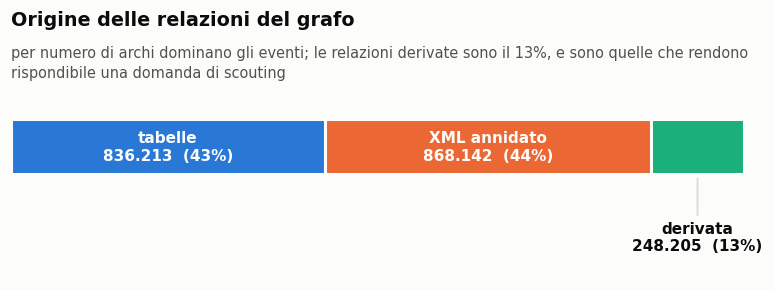

,relazioni,quota
origine,,
tabelle,836213,42.8
XML annidato,868142,44.5
derivata,248205,12.7


In [7]:
ORIGINE = {
    "PLAYS_FOR": "tabelle", "HOME_TEAM": "tabelle", "AWAY_TEAM": "tabelle",
    "RATED": "tabelle", "ASSESSED": "tabelle", "APPEARED_IN": "tabelle", "STYLE": "tabelle",
    "SCORED": "XML annidato", "OWN_GOAL": "XML annidato", "SHOT": "XML annidato",
    "FOUL": "XML annidato", "CARD": "XML annidato", "CROSS": "XML annidato",
    "CORNER": "XML annidato", "ASSISTED": "XML annidato",
    "CURRENT_TEAM": "derivata", "SEASON_TEAM": "derivata", "RANKED": "derivata",
    "FOULED": "derivata", "ASSISTED_GOALS_OF": "derivata",
}

if rels is not None:
    by_origin = (rels.assign(origine=rels["tipo"].map(ORIGINE).fillna("derivata"))
                     .groupby("origine")["n"].sum()
                     .reindex(["tabelle", "XML annidato", "derivata"]))
    total = by_origin.sum()

    fig, ax = plt.subplots(figsize=(8.6, 2.2))
    left = 0
    for (name, value), color in zip(by_origin.items(), CAT):
        ax.barh([0], [value], left=left, color=color, height=0.46, zorder=3, edgecolor=SURFACE, linewidth=2)
        share = value / total
        text = f"{name}\n{value:,.0f}".replace(",", ".") + f"  ({100*share:.0f}%)"
        if share > 0.16:                      # ci sta dentro
            ax.text(left + value / 2, 0, text, ha="center", va="center",
                    color=SURFACE, fontsize=10, fontweight="bold")
        else:                                  # segmento stretto: etichetta sotto, con guida
            ax.annotate(text, xy=(left + value / 2, -0.24), xytext=(left + value / 2, -0.62),
                        ha="center", va="top", fontsize=10, color=INK, fontweight="bold",
                        arrowprops=dict(arrowstyle="-", color=GRID, linewidth=1.2))
        left += value
    ax.set_yticks([]); ax.set_xticks([]); ax.set_xlim(0, total); ax.set_ylim(-1.1, 0.45)
    ax.spines[:].set_visible(False); ax.tick_params(length=0)
    style(ax, "Origine delle relazioni del grafo",
          "per numero di archi dominano gli eventi; le relazioni derivate sono il 13%, e sono quelle che rendono rispondibile una domanda di scouting",
          grid_axis="")
    plt.show()
    display(by_origin.rename("relazioni").to_frame().assign(quota=lambda d: (100*d["relazioni"]/total).round(1)))

---

## 3. Le relazioni e la loro semantica

Due esempi di conoscenza derivata, letti dal grafo.

### 3.1 Il ruolo, ricavato dalle coordinate di schieramento

La sorgente non dice che ruolo abbia un giocatore. Le colonne `home_player_X/Y` del `Match` sono le **coordinate in formazione**: Y è la linea di campo, X la posizione orizzontale. La cella più frequente della griglia di un giocatore dà il suo ruolo, validato su profili noti (Lloris e Neuer sempre in (1,1), Chiellini (6,3), Pirlo (5,7), Robben (3,8)).

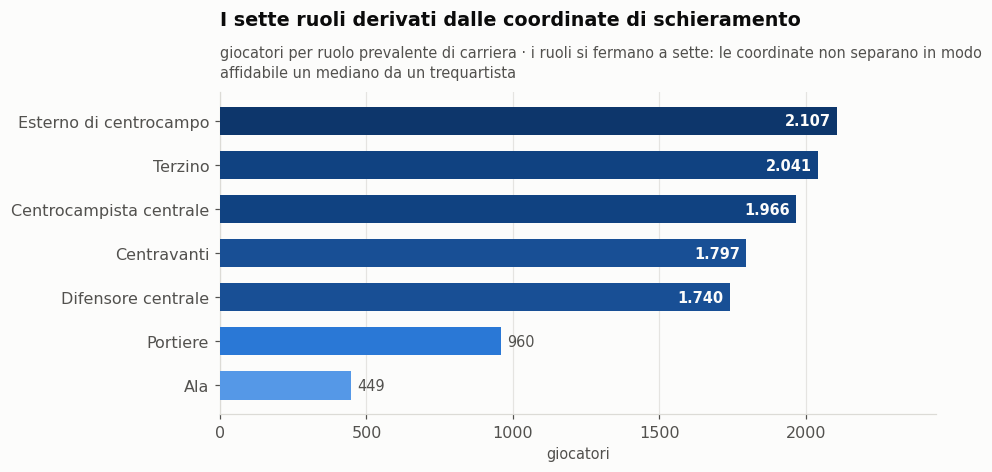

,ruolo_ita,reparto,giocatori
0,Esterno di centrocampo,midfielder,2107
1,Terzino,defender,2041
2,Centrocampista centrale,midfielder,1966
3,Centravanti,forward,1797
4,Difensore centrale,defender,1740
5,Portiere,goalkeeper,960
6,Ala,forward,449


In [8]:
roles = graph_query("""
    MATCH (p:Player) WHERE p.position IS NOT NULL
    RETURN p.position AS ruolo, p.role AS reparto, count(*) AS n ORDER BY n DESC
""")
ITA = {"goalkeeper": "Portiere", "centre_back": "Difensore centrale", "full_back": "Terzino",
       "central_midfielder": "Centrocampista centrale", "wide_midfielder": "Esterno di centrocampo",
       "striker": "Centravanti", "winger": "Ala"}

if roles is not None and not roles.empty:
    roles["ruolo_ita"] = roles["ruolo"].map(ITA).fillna(roles["ruolo"])
    order = roles.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8.4, 3.8))
    bars = ax.barh(order["ruolo_ita"], order["n"], color=seq_scale(order["n"].tolist()), height=0.64, zorder=3)
    bar_labels(ax, bars, order["n"].tolist())
    ax.set_xlim(0, roles["n"].max() * 1.16)
    style(ax, "I sette ruoli derivati dalle coordinate di schieramento",
          "giocatori per ruolo prevalente di carriera · i ruoli si fermano a sette: le coordinate non separano in modo affidabile un mediano da un trequartista",
          xlabel="giocatori")
    plt.show()
    display(roles[["ruolo_ita", "reparto", "n"]].rename(columns={"n": "giocatori"}))

### 3.2 La serie temporale delle valutazioni

`Player_Attributes` porta una rilevazione ogni poche settimane. Il grafo le tiene entrambe: `ASSESSED` è la serie completa (per le domande sull'andamento *dentro* una stagione), `RATED` è la vista condensata a una per stagione — ed è la vista predefinita del prompt, perché non ripete mai un giocatore e costa un terzo del tempo (`README.md` §6.5).

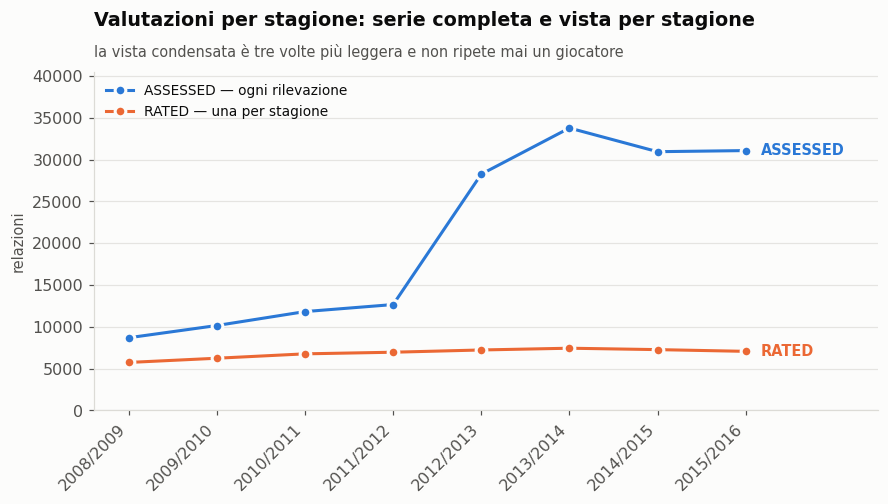

,stagione,rated,assessed
0,2008/2009,5730,8686
1,2009/2010,6235,10148
2,2010/2011,6759,11814
3,2011/2012,6953,12654
4,2012/2013,7222,28250
5,2013/2014,7432,33766
6,2014/2015,7264,30936
7,2015/2016,7057,31068


In [9]:
series = graph_query("""
    MATCH (p:Player)-[r:RATED]->(s:Season) WITH s.name AS stagione, count(r) AS rated
    MATCH (p2:Player)-[a:ASSESSED]->(s2:Season) WHERE s2.name = stagione
    RETURN stagione, rated, count(a) AS assessed ORDER BY stagione
""")

if series is not None and not series.empty:
    fig, ax = plt.subplots(figsize=(9.2, 4.0))
    for (column, label), color in zip([("assessed", "ASSESSED — ogni rilevazione"),
                                       ("rated", "RATED — una per stagione")], CAT):
        ax.plot(series["stagione"], series[column], color=color, linewidth=2,
                marker="o", markersize=7, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3, label=label)
        ax.annotate(label.split(" — ")[0], (len(series) - 1, series[column].iloc[-1]),
                    textcoords="offset points", xytext=(10, 0), ha="left", va="center",
                    fontsize=9.5, color=color, fontweight="bold")
    ax.set_xticks(range(len(series)), series["stagione"], rotation=45, ha="right")
    ax.set_xlim(-0.4, len(series) - 1 + 1.5)      # spazio per le etichette dirette
    ax.set_ylim(0, series["assessed"].max() * 1.2)
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    style(ax, "Valutazioni per stagione: serie completa e vista per stagione",
          "la vista condensata è tre volte più leggera e non ripete mai un giocatore", ylabel="relazioni", grid_axis="y")
    plt.show()
    display(series)

---

## 4. I risultati della valutazione

Il benchmark (`evaluation/benchmark.json`) è fatto di 33 casi e 55 formulazioni, ognuna con una **verità calcolata da un Cypher scritto a mano** ed eseguita sullo stesso grafo. `evaluation/run_benchmark.py` lo esegue e registra, per ogni domanda, se l'insieme dei nomi restituiti coincide con la verità, quanti tentativi sono serviti, quali guardrail sono intervenuti e quanto tempo ha preso ogni fase.

Le due configurazioni confrontate sono **lo stesso modello con lo stesso prompt**: cambia solo se i controlli in codice sono attivi.

In [10]:
def load_run(tag):
    path = RESULTS / f"{tag}.json"
    if not path.exists():
        print(f"[{tag}.json non presente]"); return None
    payload = json.loads(path.read_text(encoding="utf-8"))
    frame = pd.DataFrame(payload["records"])
    frame["tag"] = tag
    frame["guardrails"] = payload["guardrails"]
    for phase in ("generate_ms", "database_ms", "evidence_ms", "explain_ms", "total_ms"):
        frame[phase] = frame["timings"].apply(lambda t: (t or {}).get(phase))
    return frame

baseline, ablation = load_run("baseline"), load_run("no-guardrails")
runs = {"Con guardrail": baseline, "Senza guardrail": ablation}

def efficacy(frame):
    sets = frame[frame["kind"] == "set"]
    refusals = frame[frame["kind"] == "refusal"]
    answered = frame[frame["kind"] != "refusal"]
    return {
        "Insieme esatto": 100 * sets["correct"].mean(),
        "Precision sui nomi": 100 * sets["precision"].mean(),
        "Recall sui nomi": 100 * sets["recall"].mean(),
        "Rifiuti corretti": 100 * refusals["correct"].mean(),
        "Risposte sbagliate in silenzio": 100 * sets["silent_wrong"].mean(),
        "_domande": len(frame), "_insiemi": len(sets),
    }

summary = pd.DataFrame({name: efficacy(frame) for name, frame in runs.items() if frame is not None}).T
display(summary.round(1))

,Insieme esatto,Precision sui nomi,Recall sui nomi,Rifiuti corretti,Risposte sbagliate in silenzio,_domande,_insiemi
Con guardrail,93.0,97.9,96.2,100.0,7.0,110.0,100.0
Senza guardrail,64.0,77.9,80.5,25.0,32.0,55.0,50.0


### 4.1 Il risultato principale

I due numeri che riassumono il progetto. Sono la stessa domanda posta allo stesso modello: la differenza è tutta nei controlli.

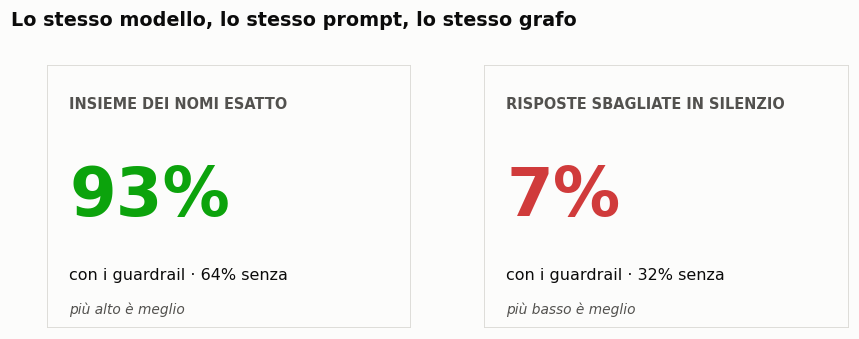

In [11]:
if baseline is not None and ablation is not None:
    tiles = [
        ("Insieme dei nomi esatto", summary.loc["Con guardrail", "Insieme esatto"],
         summary.loc["Senza guardrail", "Insieme esatto"], "più alto è meglio", GOOD),
        ("Risposte sbagliate in silenzio", summary.loc["Con guardrail", "Risposte sbagliate in silenzio"],
         summary.loc["Senza guardrail", "Risposte sbagliate in silenzio"], "più basso è meglio", CRIT),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.1))
    for ax, (label, with_g, without_g, hint, accent) in zip(axes, tiles):
        ax.axis("off")
        ax.text(0.06, 0.88, label.upper(), fontsize=9.5, color=INK_SOFT, va="top", fontweight="bold")
        ax.text(0.06, 0.50, f"{with_g:.0f}%", fontsize=44, color=accent, va="center", fontweight="bold")
        ax.text(0.06, 0.20, f"con i guardrail · {without_g:.0f}% senza", fontsize=10.5, color=INK, va="center")
        ax.text(0.06, 0.07, hint, fontsize=9, color=INK_SOFT, va="center", style="italic")
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor=GRID, linewidth=1.2))
    fig.suptitle("Lo stesso modello, lo stesso prompt, lo stesso grafo", x=0.09, y=1.04,
                 ha="left", fontsize=12.5, fontweight="bold")
    plt.show()

### 4.2 Efficacia, metrica per metrica

Le cinque misure di efficacia a confronto. "Risposte sbagliate in silenzio" — righe restituite, ma insieme diverso dalla verità — è la metrica che la tesi del progetto vuole azzerare: è l'unico errore che il lettore non può vedere.

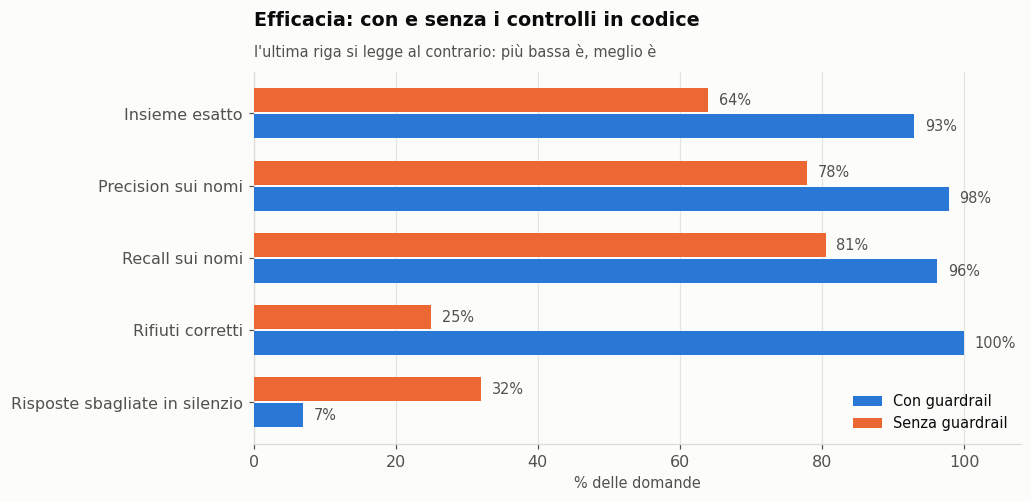

,Con guardrail,Senza guardrail
Insieme esatto,93.0,64.0
Precision sui nomi,97.9,77.9
Recall sui nomi,96.2,80.5
Rifiuti corretti,100.0,25.0
Risposte sbagliate in silenzio,7.0,32.0


In [12]:
if baseline is not None and ablation is not None:
    metrics = ["Insieme esatto", "Precision sui nomi", "Recall sui nomi",
               "Rifiuti corretti", "Risposte sbagliate in silenzio"]
    data = summary[metrics].T
    y = range(len(metrics))
    height = 0.36

    fig, ax = plt.subplots(figsize=(9.0, 4.4))
    for offset, (name, color) in zip((height / 2, -height / 2), zip(data.columns, CAT)):
        positions = [i + offset for i in y]
        bars = ax.barh(positions, data[name], height=height - 0.03, color=color, zorder=3, label=name)
        for bar, value in zip(bars, data[name]):
            ax.text(value + 1.5, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%",
                    va="center", fontsize=9.5, color=INK_SOFT)
    ax.set_yticks(list(y), metrics)
    ax.invert_yaxis()
    ax.set_xlim(0, 108)
    ax.legend(frameon=False, loc="lower right", fontsize=9.5)
    style(ax, "Efficacia: con e senza i controlli in codice",
          "l'ultima riga si legge al contrario: più bassa è, meglio è", xlabel="% delle domande")
    plt.show()
    display(data.round(1))

### 4.3 Dove i controlli fanno la differenza

L'esattezza per gruppo di domande mostra che la differenza non è uniforme: le domande semplici le prende anche il modello da solo; quelle con più vincoli, con una stagione implicita o con gli eventi di gioco no.

Due letture oneste di questo grafico: sul gruppo `grafo` le due configurazioni coincidono (i punti si sovrappongono), e sul gruppo `base` l'ablazione fa *meglio* della baseline — è il caso "ruolo esterno" che in quella esecuzione la baseline sbagliò, difetto poi corretto con il guardrail `RoleMismatch` e rieseguito a parte (`results/post-fix.md`). Questi risultati sono la baseline **prima** di quelle correzioni: restano com'erano, perché una valutazione riscritta dopo aver visto gli errori non è più una valutazione.

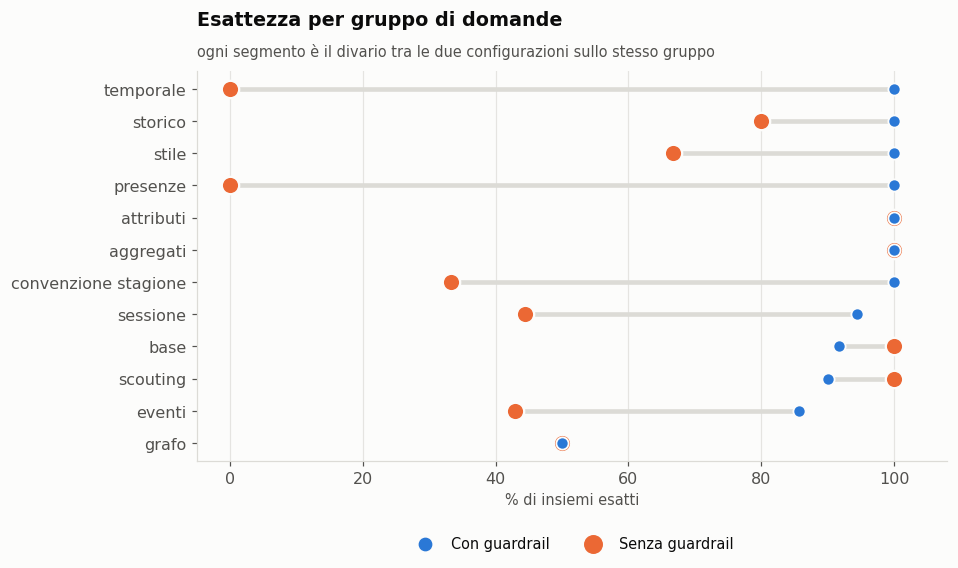

,Con guardrail,Senza guardrail
group,,
grafo,50.0,50.0
eventi,86.0,43.0
scouting,90.0,100.0
base,92.0,100.0
sessione,94.0,44.0
convenzione_stagione,100.0,33.0
aggregati,100.0,100.0
attributi,100.0,100.0
presenze,100.0,0.0


In [13]:
if baseline is not None and ablation is not None:
    def by_group(frame):
        sets = frame[frame["kind"] == "set"]
        return 100 * sets.groupby("group")["correct"].mean()

    groups = pd.DataFrame({name: by_group(frame) for name, frame in runs.items()}).dropna()
    groups = groups.sort_values("Con guardrail")
    y = range(len(groups))

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    # Dumbbell: prima → dopo per ogni gruppo, il divario è la lunghezza del segmento.
    for i, (name, row) in enumerate(groups.iterrows()):
        ax.plot([row["Senza guardrail"], row["Con guardrail"]], [i, i], color=GRID, linewidth=3, zorder=2)
        # Il cerchio arancione è più grande: dove i due valori coincidono resta visibile sotto il blu.
        ax.scatter(row["Senza guardrail"], i, s=130, color=CAT[1], zorder=3, edgecolor=SURFACE, linewidth=1.5)
        ax.scatter(row["Con guardrail"], i, s=64, color=CAT[0], zorder=4, edgecolor=SURFACE, linewidth=1.2)
    ax.scatter([], [], s=64, color=CAT[0], label="Con guardrail")
    ax.scatter([], [], s=130, color=CAT[1], label="Senza guardrail")
    ax.set_yticks(list(y), [g.replace("_", " ") for g in groups.index])
    ax.set_xlim(-5, 108)
    ax.legend(frameon=False, ncol=2, fontsize=9.5, loc="upper center", bbox_to_anchor=(0.5, -0.16))
    style(ax, "Esattezza per gruppo di domande",
          "ogni segmento è il divario tra le due configurazioni sullo stesso gruppo", xlabel="% di insiemi esatti")
    plt.show()
    display(groups.round(0))

### 4.4 I guardrail che intervengono

Ogni intervento è una query **respinta prima di arrivare al database** (o subito dopo, per i difetti visibili solo nelle righe) e rimandata al modello con il motivo. Il conteggio dice quali difetti il modello commette davvero, e quanto spesso.

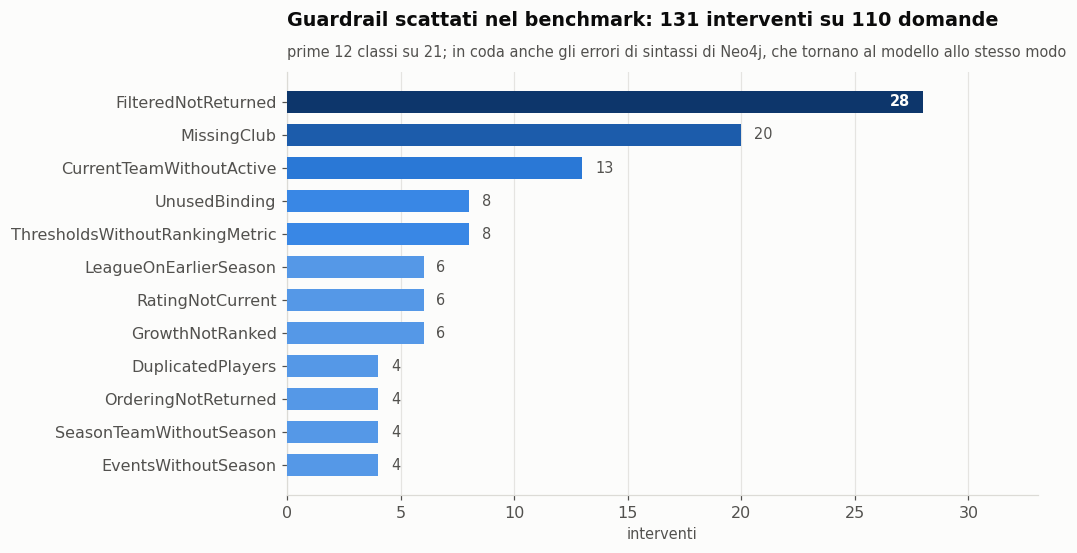

,interventi
guard_kinds,
FilteredNotReturned,28
MissingClub,20
CurrentTeamWithoutActive,13
UnusedBinding,8
ThresholdsWithoutRankingMetric,8
LeagueOnEarlierSeason,6
RatingNotCurrent,6
GrowthNotRanked,6
DuplicatedPlayers,4


In [14]:
if baseline is not None:
    fired = (baseline["guard_kinds"].explode().dropna())
    fired = fired[fired != "Neo4jError"].value_counts()
    top = fired.head(12).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    bars = ax.barh(top.index, top.values, color=seq_scale(top.values.tolist()), height=0.66, zorder=3)
    bar_labels(ax, bars, top.values.tolist(), pad=0.02)
    ax.set_xlim(0, top.max() * 1.18)
    style(ax, f"Guardrail scattati nel benchmark: {int(fired.sum())} interventi su {len(baseline)} domande",
          f"prime 12 classi su {len(fired)}; in coda anche gli errori di sintassi di Neo4j, che tornano al modello allo stesso modo",
          xlabel="interventi")
    plt.show()
    display(fired.rename("interventi").to_frame())

### 4.5 Quanti tentativi serve per una query valida

Un tentativo = una chiamata al modello. Senza guardrail la prima query viene quasi sempre accettata — ed è proprio questo il problema: nessuno la verifica.

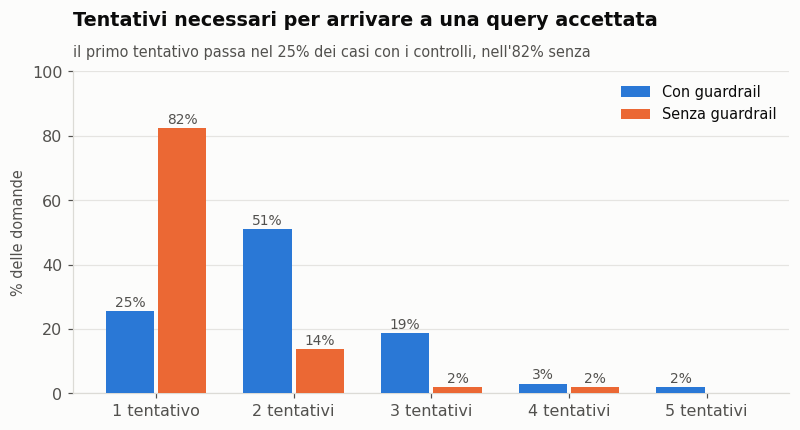

,Con guardrail,Senza guardrail
attempts,,
1.0,25.5,82.4
2.0,51.0,13.7
3.0,18.6,2.0
4.0,2.9,2.0
5.0,2.0,0.0


In [15]:
if baseline is not None and ablation is not None:
    attempts = pd.DataFrame({
        name: frame[frame["kind"] != "refusal"]["attempts"].value_counts(normalize=True).mul(100)
        for name, frame in runs.items()
    }).fillna(0).sort_index()
    x = range(len(attempts))
    width = 0.38

    fig, ax = plt.subplots(figsize=(8.4, 3.8))
    for offset, (name, color) in zip((-width/2, width/2), zip(attempts.columns, CAT)):
        positions = [i + offset for i in x]
        bars = ax.bar(positions, attempts[name], width=width - 0.03, color=color, zorder=3, label=name)
        for bar, value in zip(bars, attempts[name]):
            if value > 1:
                ax.text(bar.get_x() + bar.get_width()/2, value + 1.5, f"{value:.0f}%",
                        ha="center", fontsize=9, color=INK_SOFT)
    ax.set_xticks(list(x), [f"{int(a)} tentativ{'o' if a == 1 else 'i'}" for a in attempts.index])
    ax.set_ylim(0, 100)
    ax.legend(frameon=False, fontsize=9.5)
    style(ax, "Tentativi necessari per arrivare a una query accettata",
          "il primo tentativo passa nel 25% dei casi con i controlli, nell'82% senza", ylabel="% delle domande", grid_axis="y")
    plt.show()
    display(attempts.round(1))

### 4.6 Dove va il tempo

La latenza scomposta per fase, mediana sulle domande del benchmark. Il database non è il collo di bottiglia: il costo è il modello, e in particolare le riparazioni. I 1,4 secondi di differenza tra le due configurazioni sono il prezzo della correttezza.

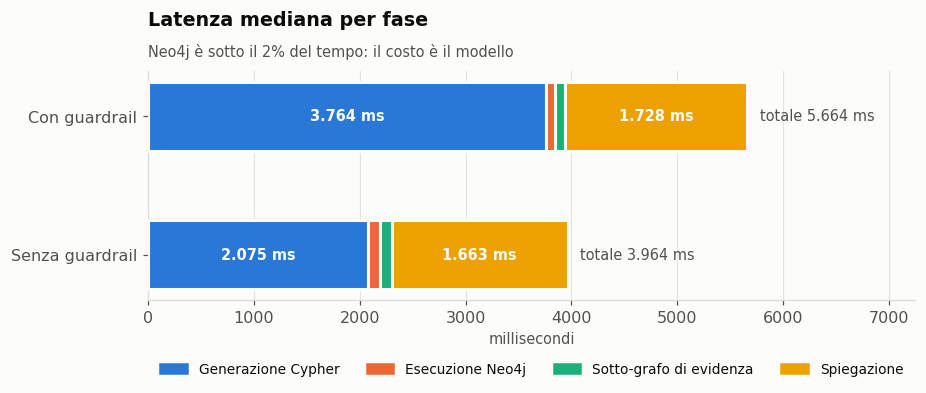

,Con guardrail,Senza guardrail
Generazione Cypher,3764,2075
Esecuzione Neo4j,78,121
Sotto-grafo di evidenza,94,105
Spiegazione,1728,1663


In [16]:
if baseline is not None and ablation is not None:
    phases = [("generate_ms", "Generazione Cypher"), ("database_ms", "Esecuzione Neo4j"),
              ("evidence_ms", "Sotto-grafo di evidenza"), ("explain_ms", "Spiegazione")]
    medians = pd.DataFrame({
        name: {label: frame[column].median() for column, label in phases}
        for name, frame in runs.items()
    })

    fig, ax = plt.subplots(figsize=(9.0, 2.7))
    for row, name in enumerate(medians.columns):
        left = 0
        for (label, color) in zip(medians.index, CAT):
            value = medians.loc[label, name]
            ax.barh([row], [value], left=left, height=0.5, color=color, zorder=3,
                    edgecolor=SURFACE, linewidth=2)
            if value > 250:   # etichetta diretta dove ci sta: la relief rule delle tinte chiare
                ax.text(left + value/2, row, f"{value:,.0f}".replace(",", ".") + " ms",
                        ha="center", va="center", fontsize=9.5, color=SURFACE, fontweight="bold")
            left += value
        ax.text(left + 120, row, f"totale {left:,.0f} ms".replace(",", "."), va="center", fontsize=9.5, color=INK_SOFT)
    ax.set_yticks(range(len(medians.columns)), medians.columns)
    ax.invert_yaxis()
    ax.set_xlim(0, medians.sum().max() * 1.28)
    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in CAT[:len(medians)]]
    ax.legend(handles, medians.index, frameon=False, ncol=4, fontsize=9,
              loc="upper center", bbox_to_anchor=(0.5, -0.22))
    style(ax, "Latenza mediana per fase", "Neo4j è sotto il 2% del tempo: il costo è il modello", xlabel="millisecondi")
    plt.show()
    display(medians.round(0).astype(int))

### 4.7 La scala delle traversate

Questa è l'unica tabella **riportata da documento** e non ricalcolata: l'esperimento sulla scala delle traversate, `README.md` §6.5 richiede il riavvio di Neo4j per la condizione a cache fredda, e ripeterlo qui invaliderebbe la cache del notebook. I numeri sono le mediane a caldo su nove esecuzioni, misurate sul grafo di allora (919.232 relazioni).

Si legge così: **raddoppiare gli archi non raddoppia il tempo.** C'è un costo fisso per query di 50-100 ms che domina sui sottoinsiemi piccoli, e la crescita è sub-lineare.

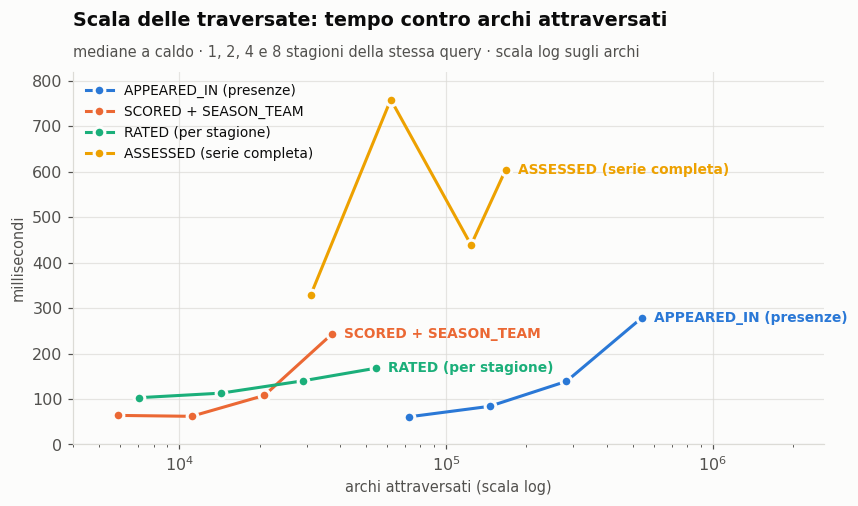

stagioni,1,2,4,8
carico,,,,
APPEARED_IN (presenze),61,84,139,279
ASSESSED (serie completa),329,759,439,605
RATED (per stagione),103,113,140,168
SCORED + SEASON_TEAM,64,62,108,243


In [17]:
# Fonte: README.md §6.5, scala delle traversate (mediane a caldo, 9 esecuzioni).
SCALA = pd.DataFrame([
    ("APPEARED_IN (presenze)",     1,  72_833,  61), ("APPEARED_IN (presenze)", 2, 145_593,  84),
    ("APPEARED_IN (presenze)",     4, 282_546, 139), ("APPEARED_IN (presenze)", 8, 542_267, 279),
    ("SCORED + SEASON_TEAM",       1,   5_878,  64), ("SCORED + SEASON_TEAM",   2,  11_098,  62),
    ("SCORED + SEASON_TEAM",       4,  20_823, 108), ("SCORED + SEASON_TEAM",   8,  37_303, 243),
    ("RATED (per stagione)",       1,   7_057, 103), ("RATED (per stagione)",   2,  14_321, 113),
    ("RATED (per stagione)",       4,  28_975, 140), ("RATED (per stagione)",   8,  54_652, 168),
    ("ASSESSED (serie completa)",  1,  31_068, 329), ("ASSESSED (serie completa)", 2, 62_004, 759),
    ("ASSESSED (serie completa)",  4, 124_020, 439), ("ASSESSED (serie completa)", 8, 167_322, 605),
], columns=["carico", "stagioni", "archi", "ms"])

fig, ax = plt.subplots(figsize=(8.8, 4.4))
for (name, group), color in zip(SCALA.groupby("carico", sort=False), CAT):
    group = group.sort_values("archi")
    ax.plot(group["archi"], group["ms"], color=color, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=3, label=name)
    ax.annotate(name, (group["archi"].iloc[-1], group["ms"].iloc[-1]), textcoords="offset points",
                xytext=(8, 0), fontsize=9, color=color, fontweight="bold", va="center")
ax.set_xscale("log")
ax.set_xlim(4_000, 2_600_000)
ax.set_ylim(0, 820)
ax.legend(frameon=False, fontsize=9, loc="upper left")
style(ax, "Scala delle traversate: tempo contro archi attraversati",
      "mediane a caldo · 1, 2, 4 e 8 stagioni della stessa query · scala log sugli archi",
      xlabel="archi attraversati (scala log)", ylabel="millisecondi", grid_axis="both")
plt.show()
display(SCALA.pivot(index="carico", columns="stagioni", values="ms"))

---

## 5. Cosa dicono questi grafici

- **Il dataset non è omogeneo** (§1.1): gli eventi di gioco coprono un terzo delle partite, e tre campionati non ne hanno alcuno. Ogni risposta che li usa lo dichiara; ogni totale porta accanto il numero di partite coperte.
- **La conoscenza derivata è poca per volume, decisiva per uso** (§2.1): è il 13% degli archi — ruolo, club di stagione, club attuale, classifiche, falli subiti, coppie gol-assist — e non esiste nella sorgente. È questa la parte che rende rispondibili le domande di scouting.
- **La correttezza è dei controlli, non del modello** (§4.1-4.3): lo stesso modello con lo stesso prompt passa dal 64% al 93% di insiemi esatti, e le risposte sbagliate in silenzio scendono dal 32% al 7%.
- **Il prezzo è tempo, non accuratezza** (§4.5-4.6): senza controlli il sistema accetta la prima query nell'82% dei casi ed è 1,4 s più veloce. È lo scambio che il progetto dichiara.
- **Il database non è il collo di bottiglia** (§4.6, §4.7): Neo4j resta sotto il 2% del tempo end-to-end e scala in modo sub-lineare con gli archi attraversati.

Per i dettagli: `README.md` §6 (protocolli, benchmark, catalogo dei difetti e limiti) e §2 (come i pezzi dialogano).